# Demo: Iterated singing

In [1]:
# Before starting, set the right working dir and imports
import os
if 'path_to_dir' not in globals():
    path_to_dir = os.path.split(os.getcwd())[0]
os.chdir(path_to_dir)

# imports
import time
import numpy as np
import shutil
import matplotlib.pyplot as plt
%matplotlib inline

from sing4me import singing_extract as sing
from sing_experiments import melodies, params

# output directory
trial_name = "ising_demo" # name your trial here!

output_dir = "output"
output_file = f"stim_{trial_name}.wav"
recording_file = f"rec_{trial_name}.wav"
output_plot = f"plot_{trial_name}.png"

In [2]:
# Global parameters
# singing_config = params.singing_2intervals
singing_config = params.singing_long_melodies

print(singing_config["reference_mode"])

# Indicate your gender
GENDER = "male" # or "female"

print(singing_config)

pitch_mode
{'sing_duration': 6, 'max_abs_interval_error_treshold': 5.5, 'max_melody_pitch_range': 99, 'num_int': 4, 'reference_mode': 'pitch_mode', 'max_pitch_height_seed': 9.5, 'max_pitch_height': 15, 'discrete': False, 'max_mean_interval_error': 5.5, 'sample_rate': 44100, 'peak_time_difference': 70, 'minimum_peak_height': 0.05, 'db_threshold': -22, 'db_end_threshold_realtive_2note_start': -10, 'max_vs_start_threshold_importance': 0.9, 'msec_silence': 70, 'cut_pre': 30, 'cut_post': 50, 'minimal_segment_duration': 70, 'pitch_range_allowed': [36, 75], 'singing_bandpass_range': [80, 6000], 'allowed_pitch_flactuations_witin_one_tone': 6, 'percent_of_flcatuating_within_one_tone': 20.0, 'praat_octave_jump_cost': 0.55, 'praat_high_frequncy_favoring_octave_cost': 0.03, 'praat_silence_threshold': 0.03, 'end_melody': 3.5, 'end_singing': 3.5, 'end_recording': 0.5, 'upload': 0.5, 'max_interval_size': 6.5}


## Generate melody

In [3]:
reference_pitch = melodies.sample_reference_pitch(
    params.roving_mean[GENDER],
    params.roving_width["default"]
)

# number notes per melody is flexible
# min_num_pitches = 5
# max_num_pitches = 12
# num_pitches = melodies.sample_num_pitches(min_num_pitches, max_num_pitches)

# number notes per melody is fixed
num_pitches = 5

# generate targer pitches
target_pitches = melodies.sample_absolute_pitches(
    reference_pitch=reference_pitch,
    max_pitch_height=singing_config["max_pitch_height_seed"],
    num_pitches=num_pitches
)
print(f"Melody has {num_pitches} pitches")
print(target_pitches)

Melody has 5 pitches
[40.223358505073776, 53.831618341831856, 55.218774814470144, 49.20868031390921, 44.71019051450096]


In [4]:
# select if note duratons are fixed or of varying lenght 

note_duration_fixed = False


In [5]:
# generate melodies
if note_duration_fixed:
    NOTE_DURATION = 0.5
    NOTE_IOI = 0.8
    durations = [NOTE_DURATION for _ in target_pitches]
    onsets = [i * NOTE_IOI for i in range(len(target_pitches))]
    duration_recording = (sum(onsets))

else:
    durations = [0.25, 0.25, 0.5, 0.5, 2]
    silences = [0.3] * len(durations)
    NOTE_IOI = [element1 + element2 for (element1, element2) in zip(durations, silences)] 
    NOTE_IOI.insert(0, 0)  # insert first oneset at 0 ms
    NOTE_IOI = np.cumsum(NOTE_IOI) # get onsets
    NOTE_IOI = NOTE_IOI[:-1]  # remove onset after last note
    onsets = [i for i in NOTE_IOI]
    duration_recording = (sum(onsets))
    
print(durations)
print(onsets)
print(duration_recording)

[0.25, 0.25, 0.5, 0.5, 2]
[0.0, 0.55, 1.1, 1.9000000000000001, 2.7]
6.25


In [6]:
# save audio
sing.generate_sine_tones(
    target_pitches,
    durations,
    onsets,
    singing_config["sample_rate"],
    os.path.join(output_dir,output_file)
)

## Recording

In [7]:
import sounddevice as sd
import soundfile as sf
from scipy.io import wavfile

def save_samples_to_file(samples, filename, fs):
    wavfile.write(filename, rate=fs, data=samples.astype(np.float32))

print("Listen to the melody")
audio_data, SAMPLE_RATE = sf.read(os.path.join(output_dir,output_file), dtype='float32')
sd.play(audio_data, SAMPLE_RATE)
status = sd.wait()
print("WAIT IN SILENCE..")
time.sleep(3)

print("SING THE MELODY BACK!")
myrecording = sd.rec(int((duration_recording + 2) *  SAMPLE_RATE), samplerate=  SAMPLE_RATE, channels=1)
status = sd.wait()

# save recording to wav
save_samples_to_file(
    myrecording,
    os.path.join(output_dir,recording_file),
    SAMPLE_RATE)

print("Finished")

Listen to the melody
WAIT IN SILENCE..
SING THE MELODY BACK!
Finished


## ANALYSIS

In [8]:
# Parmeters to improve extraciont

# sing4me params
singing_config["cut_pre"] = 50  # this was 110 ms (time ignored at start of segment)
singing_config["cut_post"] = 50  # this was 70 ms (time ignored at end of segment)
singing_config["msec_silence"] = 50  # this was 70 ms (min silence between segments)
# config["minimal_segment_duration"] = 35  # min time the segment should have (ms)

## Analyse: pitches

In [9]:
# compute sung pitches and intervals5
raw = sing.analyze(
    os.path.join(output_dir,recording_file),
    singing_config,
    target_pitches=target_pitches,
    plot_options=sing.PlotOptions(
        save=True, path= os.path.join(output_dir, output_plot), format="png"
    ),
)

raw = [{key: melodies.as_native_type(value) for key, value in x.items()} for x in raw]
sung_pitches = [x["median_f0"] for x in raw]
sung_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
            sung_pitches,
             "previous_note"
        )

target_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
    target_pitches,
    "previous_note"
)
pitch_heights = melodies.convert_absolute_pitches_to_pitch_heights(
    sung_pitches,
    reference_pitch
)
stats = sing.compute_stats(
    sung_pitches,
    target_pitches,
    sung_intervals,
    target_intervals
)
print(f"sung pitches: {sung_pitches}")
print(f"target pitches: {target_pitches}")
print(f"sung intervals: {sung_intervals}")
print(f"target intervals: {target_intervals}")
print(f"pitch heights: {pitch_heights}")

# print(f"stats: {stats}")

Plot saved
sung pitches: [43.74737454723015, 51.3574371438854, 54.92200456689076, 48.871306983621, 44.526186506090056]
target pitches: [40.223358505073776, 53.831618341831856, 55.218774814470144, 49.20868031390921, 44.71019051450096]
sung intervals: [7.610062596655247, 3.5645674230053643, -6.050697583269766, -4.345120477530941]
target intervals: [13.60825983675808, 1.3871564726382886, -6.010094500560932, -4.498489799408254]
pitch heights: [4.866016866155505, 2.7440457304997423, 6.308613153505107, 0.2579155702353404, 4.0872049072956]


In [10]:
# extract onsets

MIN_NOTE_DURATION = 0.25

silence_durations, note_durations, ISIs = sing.extract_onsets(raw, MIN_NOTE_DURATION)
print(f"note_durations: {note_durations}")
print(f"silence_durations: {silence_durations}")
print(f"ISIs: {ISIs}")


note_durations: [0.28621315192743757, 0.3032653061224489, 0.3251473922902492, 0.28798185941043086, 1.8753061224489793]
silence_durations: [0.37501133786848084, 0.3398412698412699, 0.6298639455782313, 0.7159863945578231, 0.5]
ISIs: [0.6612244897959184, 0.6431065759637188, 0.9550113378684806, 1.003968253968254]


In [11]:
# Failing criteria
is_failed = melodies.failing_criteria(
                sung_intervals,
                sung_pitches,
                reference_pitch,
                singing_config["num_int"],
                singing_config["max_interval_size"],
                singing_config["max_melody_pitch_range"],
                singing_config["reference_mode"],
                stats,
                singing_config["max_abs_interval_error_treshold"],
                singing_config["max_pitch_height"]
            )


print(f"Is it failed? {is_failed['failed']}")
print(f"Reason: {is_failed['reason']}")

Is it failed? False
Reason: All good


## PLOT

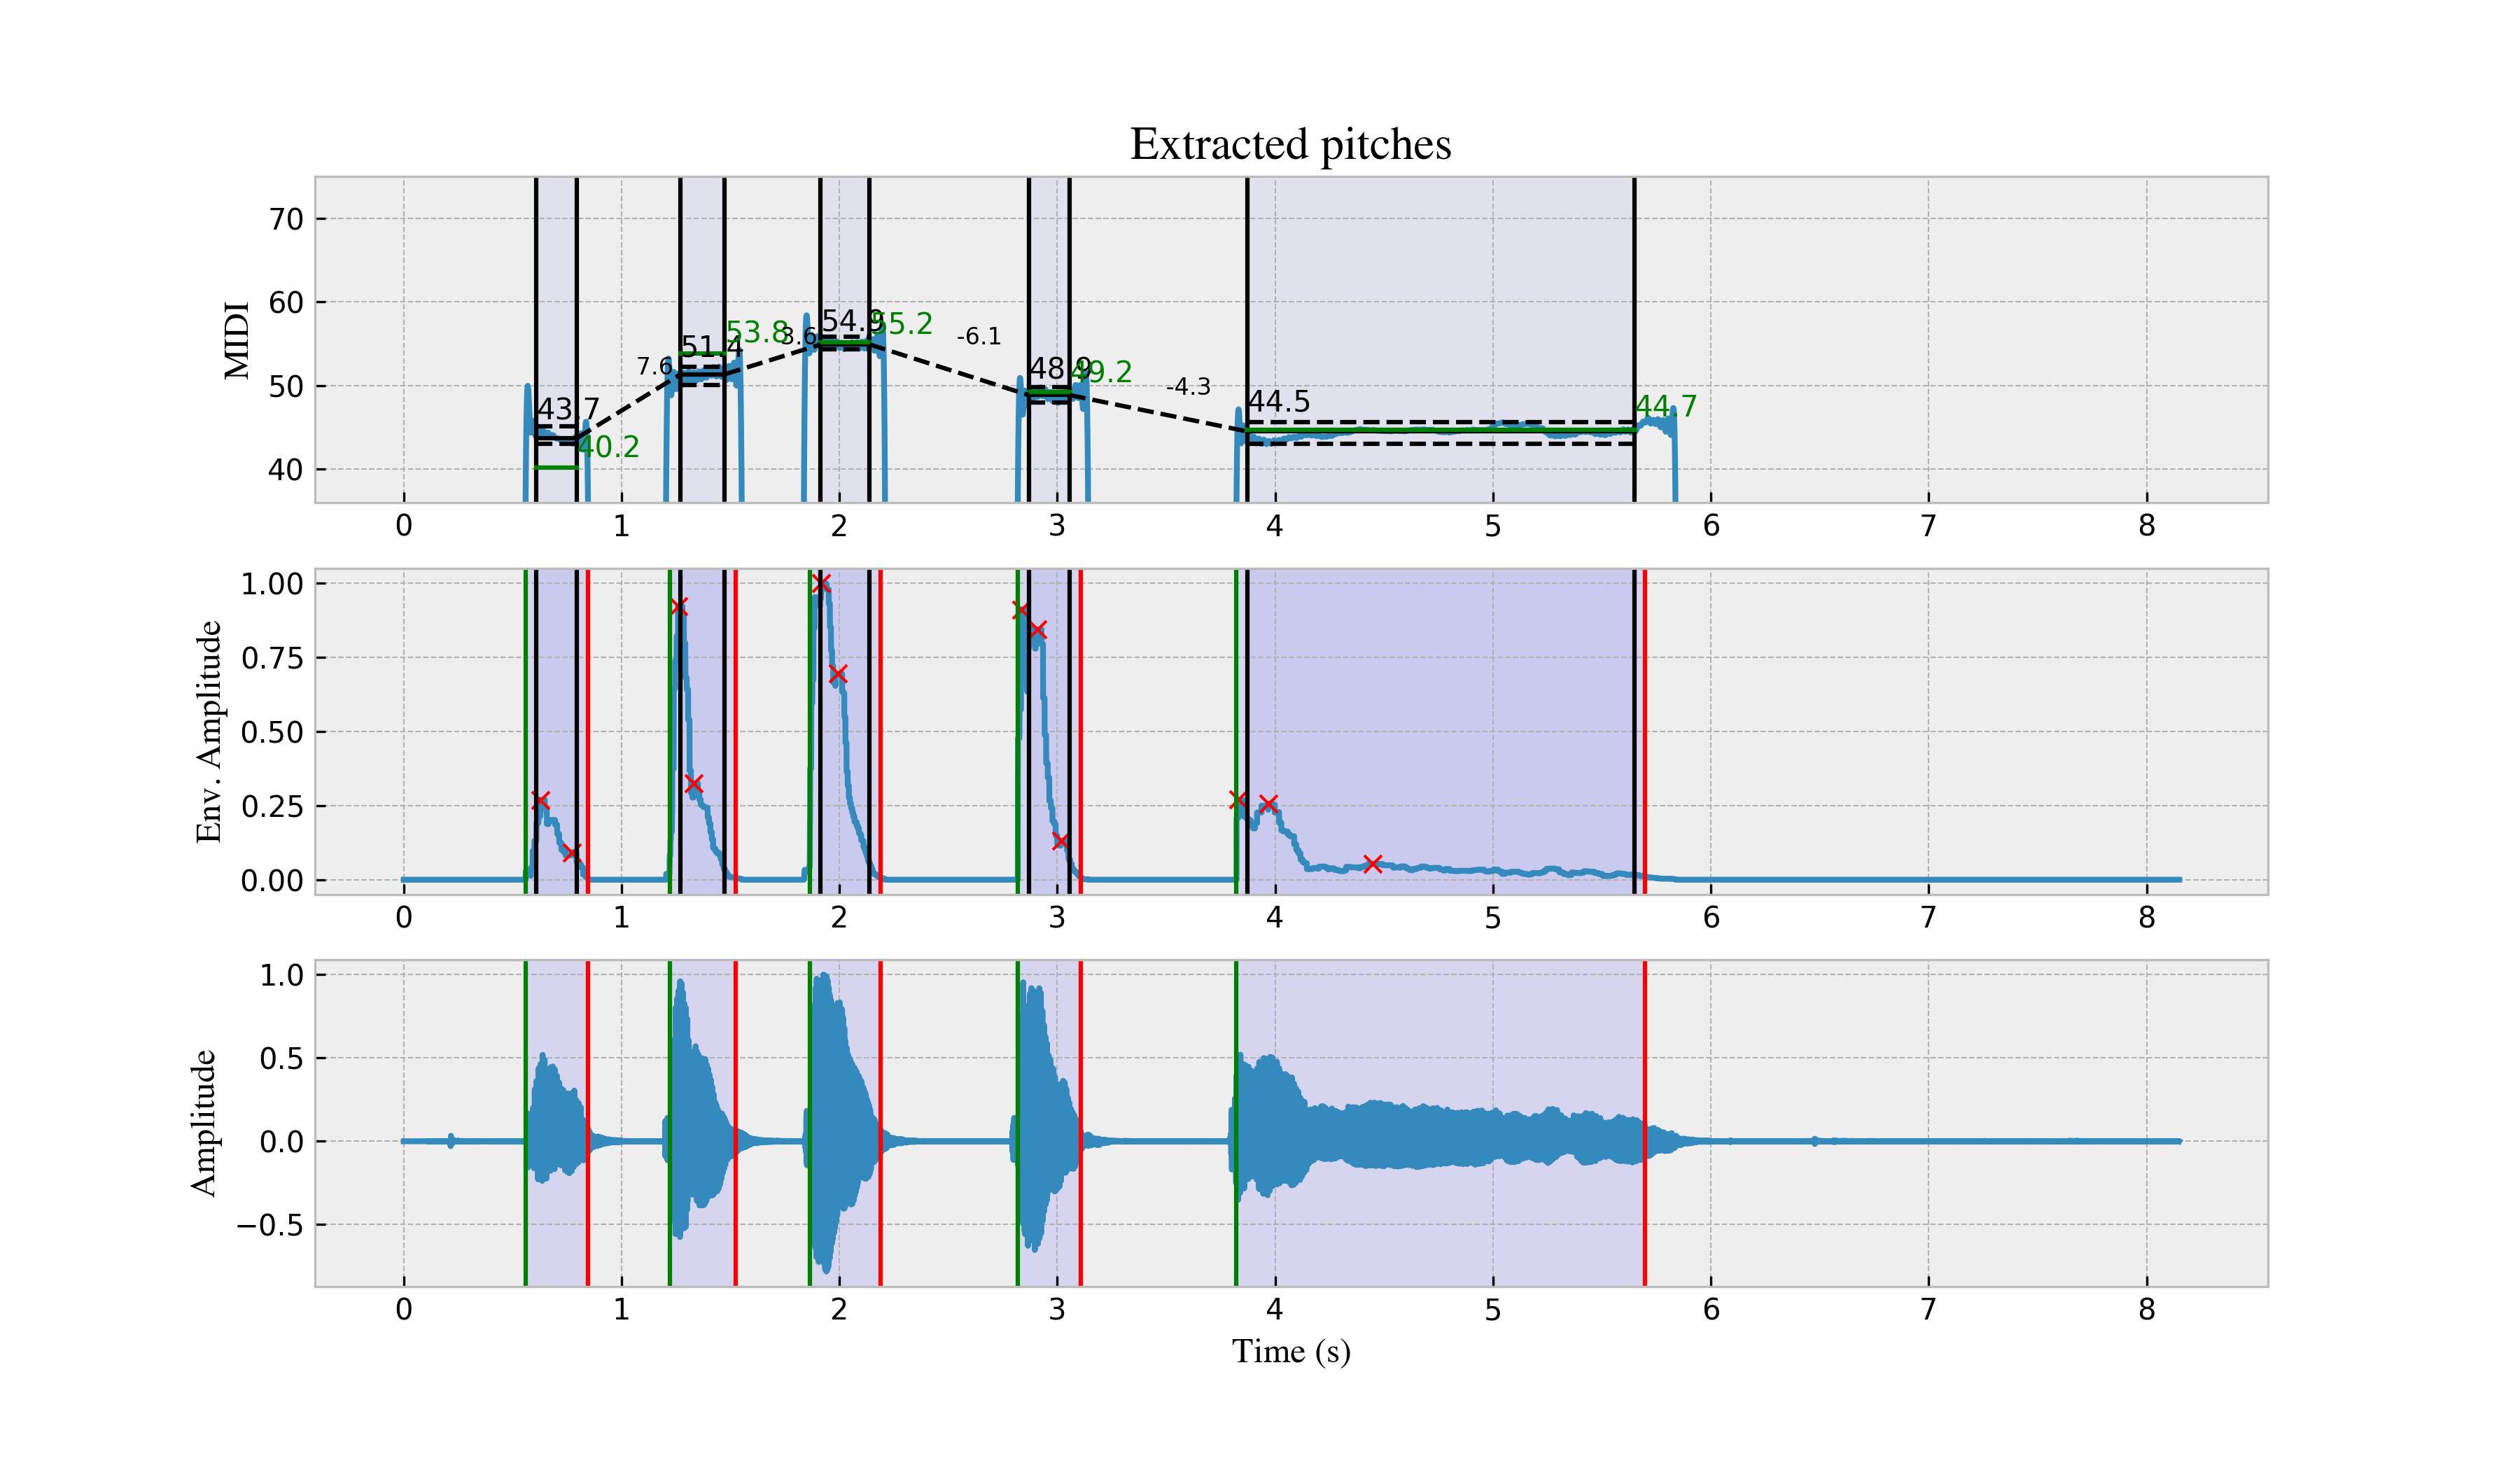

In [12]:
from IPython import display
display.Image(os.path.join(output_dir, output_plot))